In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Importing some pytorch packages
import torch
from torch.nn import Conv2d

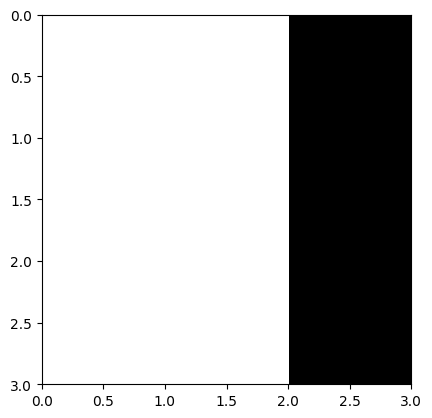

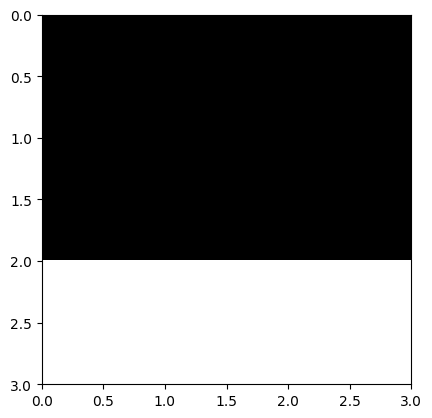

In [3]:
# 2D 3x3 binary image with vertical edge
image1 = np.array([[1,1,0], [1,1,0], [1,1,0]])

# 2D 3x3 binary image with horizontal edge
image2 = np.array([[0,0,0], [0,0,0], [1,1,1]])

# On plotting the images
plt.imshow(image1, cmap='gray', extent=[0, 3, 3, 0])
plt.show()
plt.imshow(image2, cmap='gray', extent=[0, 3, 3, 0])
plt.show()

In [4]:
# Vertical Line filter
filter = np.array([[1,0,-1],
                   [1,0,-1],
                   [1,0,-1]])

# Applying filter to first image
output = np.sum(np.multiply(image1, filter))
print('Output from first image: ', output)

# Applying filter to second image
output = np.sum(np.multiply(image2, filter))
print('Output from second image: ', output)

Output from first image:  3
Output from second image:  0


In [5]:
# Horizontal edge filter
filter = np.array([[-1,-1,-1],
                   [ 0, 0, 0],
                   [ 1, 1, 1]])

output = np.sum(np.multiply(image1, filter))
print('Output from first image: ', output)

output = np.sum(np.multiply(image2, filter))
print('Output from second image: ', output)

Output from first image:  0
Output from second image:  3


In [6]:
def apply_conv(image, kernel, padding=0, stride=1):

  #--------IMAGE PREPROCESSING-------
  image = torch.from_numpy(image)
  # Pytorch requires input to convolution in (N,C,H,W), where N = batch size and C=#channels in input
  input = image.view((1,1,image.shape[0], image.shape[1]))

  # --------------KERNEL-------------
  kernel = torch.from_numpy(kernel.astype(np.float32))

  # Pytorch requires kernel of shape (N,C,H,W), where N = batch size and C=#channels in input
  kernel = kernel.view((1,1,kernel.shape[0], kernel.shape[1]))

  # ---------CONVOLUTION LAYER from Pytorch--------
  conv = Conv2d(in_channels=1, out_channels=1, kernel_size=kernel.shape, padding=padding, stride=stride)

  # Set the kernel weights in the convolution layer
  conv.weight = torch.nn.Parameter(kernel)

  # ---------APPLY CONVOLUTION--------
  output = conv(input.float())
  output_img = output.data.numpy()  # Tensor to back in numpy
  output_img = output_img.reshape((-1, output_img.shape[-1])) # Reshape to 2D image

  return output_img

In [9]:

# Our original lotus image
image = cv2.imread('/content/grid1 (1).jpg', 0)

# Check if image loading was successful
if image is None:
    print("Error: Could not load image. Please check the file path.")
else:
    filter = np.array([[-1, -1, -1],
                       [0, 0, 0],
                       [1, 1, 1]])

    out1 = apply_conv(image, filter, padding=0, stride=1)

    filter = np.array([[1, 0, -1],
                       [1, 0, -1],
                       [1, 0, -1]])

    out2 = apply_conv(image, filter, padding=0, stride=1)

In [10]:
# Import packages
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [11]:
#  Images returned from torchvision dataset classes is in range [0,1]
# We transform them to tensors and normalize them to range [-1,1] using 'Normalize' transform

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

# Classes in CIFAR10
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:03<00:00, 49.0MB/s]


In [12]:
print('Training data shape : ', trainset.data.shape, len(trainset.targets))
print('Testing data shape : ', testset.data.shape, len(testset.targets))

# Find the unique numbers from the train labels
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Training data shape :  (50000, 32, 32, 3) 50000
Testing data shape :  (10000, 32, 32, 3) 10000
Total number of outputs :  10
Output classes :  ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [13]:
def train(num_epochs, model, train_loader, loss_func, optimizer):

  # Training mode
  model.train()

  train_losses = []
  train_acc = []

  # Train the model
  for epoch in range(num_epochs):
    running_loss = 0
    running_acc = 0
    for i, (images, labels) in enumerate(train_loader):

      # clear gradients for this training step
      optimizer.zero_grad()

      # Forward pass
      output = model(images)

      # Calculate loss
      loss = loss_func(output, labels)

      # Backpropagation, compute gradients
      loss.backward()

      # Apply gradients
      optimizer.step()

      # Running loss
      running_loss += loss.item()

      # indices of max probabilities
      _, preds = torch.max(output, dim=1)

      # Calculate number of correct predictions
      correct = (preds.float() == labels).sum()
      running_acc += correct

      # Average loss and acc values
      epoch_loss = running_loss / len(train_loader.dataset)
      epoch_acc = running_acc / len(train_loader.dataset)

    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)
    print ('Epoch {}/{}, Loss: {:.4f}, Accuracy: {:.4f}'.format(epoch + 1, num_epochs, epoch_loss, epoch_acc*100))

  return train_losses, train_acc

In [14]:
def test_model(model, testloader):
  correct = 0
  total = 0
  # Deactivate autograd engine (don't compute grads since we're not training)
  with torch.no_grad():
    for data in testloader:
        images, labels = data
        # Calculate outputs by running images through the network
        outputs = model(images)
        # The class with the highest value is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

  print('Accuracy of the network: %d %%' % (
      100 * correct / total))

In [15]:
# CNN with 2 CONV layers and 3 FC layers
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.fc1 = nn.Linear(32 * 5 * 5, 512)
        self.fc2 = nn.Linear(512, 128)
        # output layer 10 classes
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        # flatten all dimensions except batch
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [16]:
model = Net()
print(model)

Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=800, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [17]:
# Cross Entropy loss for multi-class classification
criterion = nn.CrossEntropyLoss()

In [18]:
#(), lr:=0.05, momentum=0.9
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9)

In [20]:
num_epochs = 5
train_losses, train_acc = train(num_epochs, model, trainloader, criterion, optimizer) # Changed 'critertion' to 'criterion'

Epoch 1/5, Loss: 0.0102, Accuracy: 52.9740
Epoch 2/5, Loss: 0.0085, Accuracy: 61.7460
Epoch 3/5, Loss: 0.0072, Accuracy: 67.5480
Epoch 4/5, Loss: 0.0062, Accuracy: 71.9740
Epoch 5/5, Loss: 0.0053, Accuracy: 76.2240


Epoch 1/5 | Loss: 1.6887 | Accuracy: 38.56%
Epoch 2/5 | Loss: 1.5207 | Accuracy: 46.69%
Epoch 3/5 | Loss: 1.5272 | Accuracy: 47.32%
Epoch 4/5 | Loss: 1.5279 | Accuracy: 47.94%
Epoch 5/5 | Loss: 1.5225 | Accuracy: 48.30%
Test Accuracy of the network: 46.07%


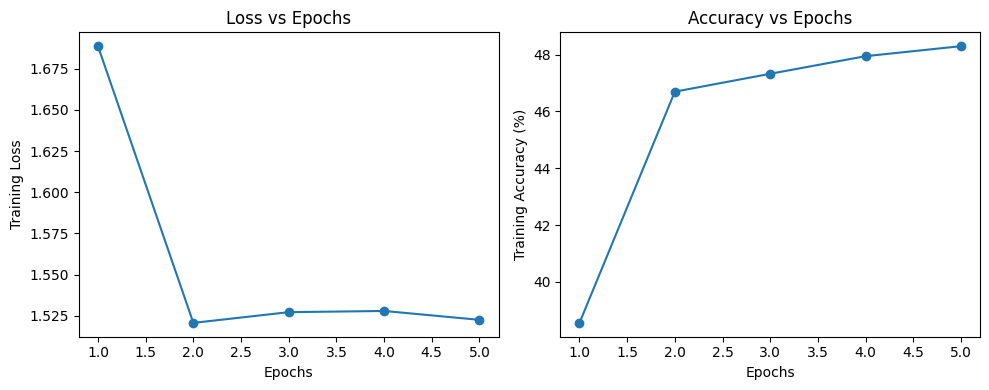

In [21]:
# Import necessary libraries
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Define the CNN Model
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3)          # Input: 3x32x32 -> Output: 16x30x30
        self.pool = nn.MaxPool2d(2, 2)            # Output: 16x15x15
        self.conv2 = nn.Conv2d(16, 32, 5)         # Output: 32x11x11
        self.fc1 = nn.Linear(32 * 5 * 5, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 10)             # Output for 10 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))      # After conv1 & pool
        x = self.pool(F.relu(self.conv2(x)))      # After conv2 & pool
        x = torch.flatten(x, 1)                   # Flatten the output
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Training function
def train(num_epochs, model, train_loader, loss_func, optimizer):
    model.train()
    train_losses = []
    train_acc = []

    for epoch in range(num_epochs):
        running_loss = 0.0
        running_correct = 0
        total = 0

        for i, (images, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(images)
            loss = loss_func(output, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(output, 1)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = running_correct / total

        train_losses.append(epoch_loss)
        train_acc.append(epoch_acc)

        print('Epoch {}/{} | Loss: {:.4f} | Accuracy: {:.2f}%'.format(
            epoch + 1, num_epochs, epoch_loss, epoch_acc * 100))

    return train_losses, train_acc

# Test function
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print('Test Accuracy of the network: {:.2f}%'.format(100 * correct / total))


# -----------------------------------------------
# CIFAR-10 Dataset Loading
# -----------------------------------------------
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 32

train_set = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size,
                                           shuffle=True, num_workers=2)

test_set = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size,
                                          shuffle=False, num_workers=2)

# -----------------------------------------------
# Model, Loss, Optimizer
# -----------------------------------------------
model = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9)

# -----------------------------------------------
# Train the model
# -----------------------------------------------
num_epochs = 5
train_losses, train_acc = train(num_epochs, model, train_loader, criterion, optimizer)

# -----------------------------------------------
# Test the model
# -----------------------------------------------
test_model(model, test_loader)

# -----------------------------------------------
# Plotting training loss and accuracy
# -----------------------------------------------
plt.figure(figsize=(10, 4))

# Plot training loss
plt.subplot(1, 2, 1)
plt.plot(np.arange(1, len(train_losses) + 1), train_losses, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Loss vs Epochs')

# Plot training accuracy
plt.subplot(1, 2, 2)
plt.plot(np.arange(1, len(train_acc) + 1), [acc * 100 for acc in train_acc], marker='o')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy (%)')
plt.title('Accuracy vs Epochs')

plt.tight_layout()
plt.show()

In [22]:
# Import necessary libraries
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# ... (Your existing code for Net class, train function, and test_model function) ...

# Create an instance of the model
model = Net()  # Define the model before using it

# Cross Entropy loss for multi-class classification
criterion = nn.CrossEntropyLoss()

# SGD optimizer with momentum
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9)

# ... (Rest of your training and testing code) ...

Epoch 1/5 | Loss: 1.6774 | Accuracy: 38.40%
Epoch 2/5 | Loss: 1.2246 | Accuracy: 56.63%
Epoch 3/5 | Loss: 1.0298 | Accuracy: 63.76%
Epoch 4/5 | Loss: 0.8791 | Accuracy: 69.14%
Epoch 5/5 | Loss: 0.7649 | Accuracy: 73.17%


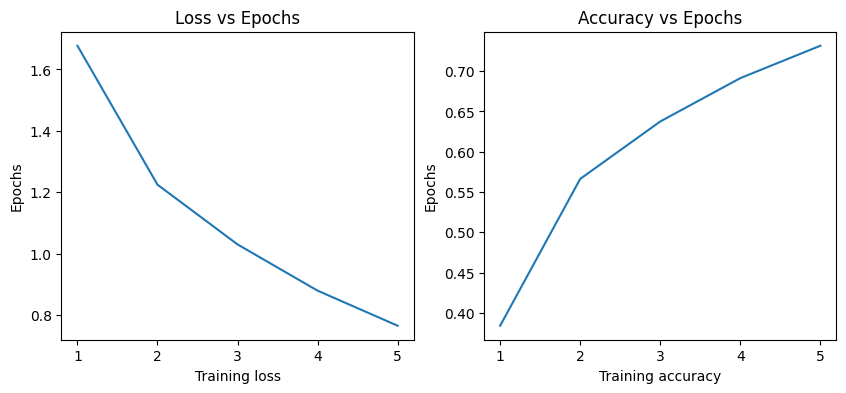

In [23]:
# ... previous code ...

# Create an instance of the model
model = Net()

# Cross Entropy loss for multi-class classification
criterion = nn.CrossEntropyLoss()

# SGD optimizer with momentum
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9)

# Number of training epochs
num_epochs = 5  # iterations

# Train the model and get the training losses and accuracy
train_losses, train_acc = train(num_epochs, model, trainloader, criterion, optimizer) # Call the train function

# Plotting code
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(np.arange(1, len(train_losses) + 1), train_losses)
plt.xlabel('Training loss')
plt.ylabel('Epochs')
ax.set_title('Loss vs Epochs')
ax = fig.add_subplot(1, 2, 2)
ax.plot(np.arange(1, len(train_acc) + 1), train_acc)
plt.xlabel('Training accuracy')
plt.ylabel('Epochs')
ax.set_title('Accuracy vs Epochs')
plt.show()

In [24]:
# Accuracy on test data after training
test_model(model, testloader)
# Import packages
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# ... (rest of your code) ...

# CNN with 2 CONV layers and 3 FC layers
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.fc1 = nn.Linear(32 * 5 * 5, 512)
        self.fc2 = nn.Linear(512, 128)
        # output layer 10 classes
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        # flatten all dimensions except batch
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Create an instance of the model
model = Net()

Test Accuracy of the network: 67.13%
